# Abstract

Here we investigate the expected ability of a new remote-sensing stand-off infrared spectrometer, *Enfys*, for the ExoMars Rosalind Franklin Rover, to resolve diagnostic features of the reflectance spectra of key minerals previously identified on the surface of Mars.

# Introduction

## Background
The ESA ExoMars Rosalind Franklin Rover is planned to land at the Oxia Planum region of Mars [ref] to characterise the geochemical and aqueous history of the environment and near subsurface (<2 m), and search for signs of past or present life [ref].

Previously the rover payload included a ROSCOSMOS (Russian) led instrument, the Infrared Spectrometer for ExoMars (ISEM) [ref]. Following the geopolitical fallout of the Russian invasion of Ukraine in 2021 the ISEM instrument was removed from the rover. A new UK-led instrument, *Enfys* (Welsh for 'rainbow'), has been approved at the ESA ministerial level to replace it.

The purpose of the spectrometer is to provide high-spectral resolution observations of points of interest found in panoramic colour and multispectral image products, captured by the mast-mounted PanCam instrument [ref] of the rover. The short-wave infrared range is sensitive to the IR-active H2O, OH, and CO3 molecules found in the carbonates and hydrated clays, sulphates and silicates that have been found previously on Mars, and that give insights to the geochemical and aqueous history of the environment. The high spectral resolution is required to resolve the subtle changes in the IR-active molecule band depths, positions and asymmetries that are induced by the presence of the various other elements and molecules in different mineral groups, species and phases.

## Enfys
The *Enfys* infrared spectrometer uses a scanning linear-variable-filter (LVF) optical design to observe incident narrowband intensity in the spectral range of 0.9 - 3.1 µm with a spectral resolving power of ~100, and with an expected signal-to-noise ratio of >2000 at 0.9 µm and >100 at 3.1 µm [ref?]. The spectral range is covered by two photodiodes and two separate linear-variable filters; a 0.9 - 1.7 µm range filter is paired with an uncooled InGaAs photodiode, and the 1.6 - 3.1 µm range filter is paired with a cooled TE photodiode [ref].

<p align="center">
  <a href="" rel="noopener">
 <img max-width=512px src="enfys_diagram.png" alt="Enfys Diagram"></a>
</p>

## Problem
This optical design is functionally different to the Acousto-Optic Tunable Filter design of ISEM, so it is important that the design is demonstrated to fulfil the performance requirements of the instrument, and expectations of performance can be set prior to laboratory tests of the completed instrument.

At time of writing, the spectrometer is in the development stage. This notebook describes how the Spectral Parameters Toolkit [ref] can be used to convert the developing expectations of the spectral range and resolution and radiometric sensitivity of the instrument into predictions of discriminatory ability of mineral species and phases on the Mars surface at the rover landing site.

# Method

To investigate the expected performance we will use high-resolution laboratory measured spectra of a range of minerals expected at the Mars surface, and computationally simulate the sampling of the spectra with the expected spectral response of *Enfys*. We will perform repeat sampling with synthetically added noise to investigate the spectral and radiometric limits of the instrument.

We will produce a number of visualisations to investigate the predicted instrument performance, and demonstrate the limits of the instrument discriminatory ability.

## Spectral Resampling
We take a simple approach to resampling, as follows. 

We neglect the introduction of reflectance calibration uncertainty, and assume that the spectral transmission of the linear-variable filter movement is perfectly calibrated such that a measurement at central wavelength ($\lambda_{cwl}$) can be requested with arbitrary precision.

We assume an observation of $\lambda_{cwl}$ has a Cauchy transmission profile, and, prior to component characterisation, a spectral resolving power of $\lambda/\Delta\lambda=100$ is achieved for all $\lambda_{cwl}$ [ref], such that the Cauchy transmission profile for $\lambda_{cwl}$ has a full-width-at-half-maximum of $\Delta\lambda = \lambda_{cwl}/100$.

The Cauchy transmission profile $T(\lambda|\lambda_{cwl})$ is given by

$T(\lambda|\lambda_{cwl}) = \frac{\gamma^2}{(\lambda - \lambda_{cwl}^2) + \gamma^2}$

where $\gamma = \Delta\lambda/2 = \lambda_{cwl}/100/2$.

We assume that a high-resolution laboratory spectrum approximates the continuous function $R(\lambda)$, such that the calibrated reflectance at $\lambda_{cwl}$ has the expected value $R[\lambda_{cwl}]$ of:

$R[\lambda_{cwl}] = \frac{\int R(\lambda)T(\lambda|\lambda_{cwl}) d\lambda }{\int T(\lambda|\lambda_{cwl}) d\lambda}$

To simulate noise we add $\varepsilon$, an additive noise term that we draw from the Gaussian distribution with variance:

$\sigma^2 = \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}}$

under the assumption that maximum $\text{SNR}$ is only achieved for $R = 1$, and the noise follows a Poissonian relationship with the signal $R$.

For each observation $R[\lambda_{cwl}]$ we draw 100 repeat samples, such that

$R_i[\lambda_{cwl}] = R[\lambda_{cwl}] + \varepsilon_i$

with 

$\varepsilon_i \sim \mathcal{N}(0, \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}})$

## Analysis

For now, we simply produce plots of the resampled spectra. We will include more details of analysis as that is developed here.

## Notebook and Environment Setup

Here we include the required code blocks for setting up this notebook for this study.

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will be using the Spectral Parameters Toolkit [ref]. First we import the required modules.

In [7]:
import sptk.config as cfg
from sptk.material_collection import MaterialCollection
from sptk.instrument import Instrument
from sptk.observation import Observation
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

We set our simulation resolution range to extend the range of Enfys, of 0.9 - 3.1 µm, such that the long tails of the Cauchy distribution of the linear-variable-filter profiles can be accommodated during sampling. We leave our spectral resolution at 1 nm for all $\lambda$.

In [9]:
cfg.update_sample_res('wvl_min', 850)
cfg.update_sample_res('wvl_max', 3300)

Finally we set the project name.

In [10]:
PROJECT_NAME = 'enfys_mica'

# Data

For this study we are using a spectral library of minerals identified through CRISM analysis ([the MICA files](http://crism.jhuapl.edu/data/mica/)) [ref]. Here we use the laboratory spectra that have been identified that best represent the type localities presented in the MICA files. These can be accessed [here](https://crismtypespectra.rsl.wustl.edu/), and are sourced from the RELAB and USGS public spectral libraries.

We have grouped the spectral library into categories as follows, and included this categorisation in the sptk distribution, accessed from the ```sptk.material_sets``` module.

In [13]:
from sptk.material_sets import MICA_SET

In [16]:
for category in MICA_SET.keys():
    print(category.title())
    for species in MICA_SET[category]:
        print('|____'+species[0].title())

Iron Oxides & Primary Silicates
|____Hematite
|____Forsterite
|____Fayalite
|____Plagioclase
|____Orthopyroxene
|____Clinopyroxene
Sulfates
|____Kieserite
|____Alunite
|____Jarosite
|____Mg-Sulphate
|____Gypsum
|____Bassanite
Phyllosilicates
|____Montmorillonite
|____Kaolinite
|____Margarite
|____Illite
|____Nontronite
|____Saponite
|____Talc
|____Serpentine
|____Chlorite
Carbonates
|____Magnesite
|____Calcite
Hydrated Silicates & Halides
|____Siliceous-Sinter
|____Halite
|____Epidote
|____Analcime
|____Prehnite


We use the ```sptk.material_collection``` module to parse the spectral library:

In [17]:
matcol = MaterialCollection(
        MICA_SET,
        'MICA_new_dirtree', 
        PROJECT_NAME, 
        load_existing=False,
        balance_classes=False,
        random_bias_seed=None,
        allow_out_of_bounds=True,
        plot_profiles=False,
        export_df=True)

Building new enfys_mica MaterialCollection DF

Iron Oxides & Primary Silicates: NBPP22.csv (Clinopyroxene) loaded
Iron Oxides & Primary Silicates: LAPP47B.csv (Orthopyroxene) loaded
Iron Oxides & Primary Silicates: LAPO05.csv (Fayalite) loaded
Iron Oxides & Primary Silicates: LASC02.csv (Forsterite) loaded
Iron Oxides & Primary Silicates: GDS27.csv (Hematite) loaded
Iron Oxides & Primary Silicates: NCLS04.csv (Plagioclase) loaded
Sulfates: F1CC08B.csv (Alunite) loaded
Sulfates: GDS145.csv (Bassanite) loaded
Sulfates: LASF41A.csv (Gypsum) loaded
Sulfates: LASF21A.csv (Jarosite) loaded
Sulfates: F1CC15.csv (Kieserite) loaded
Sulfates: 799F366.csv (Mg-Sulphate) loaded
Phyllosilicates: LACL14.csv (Chlorite) loaded
Phyllosilicates: LAKA04.csv (Kaolinite) loaded
Phyllosilicates: LAIL02.csv (Illite) loaded
Phyllosilicates: GDS106.csv (Margarite) loaded
Phyllosilicates: LALZ01.csv (Serpentine) loaded
Phyllosilicates: LAMO02.csv (Montmorillonite) loaded
Phyllosilicates: NCJB26.csv (Nontronite) 

We can use the ```material_collection``` plotting routines to visualise the library.

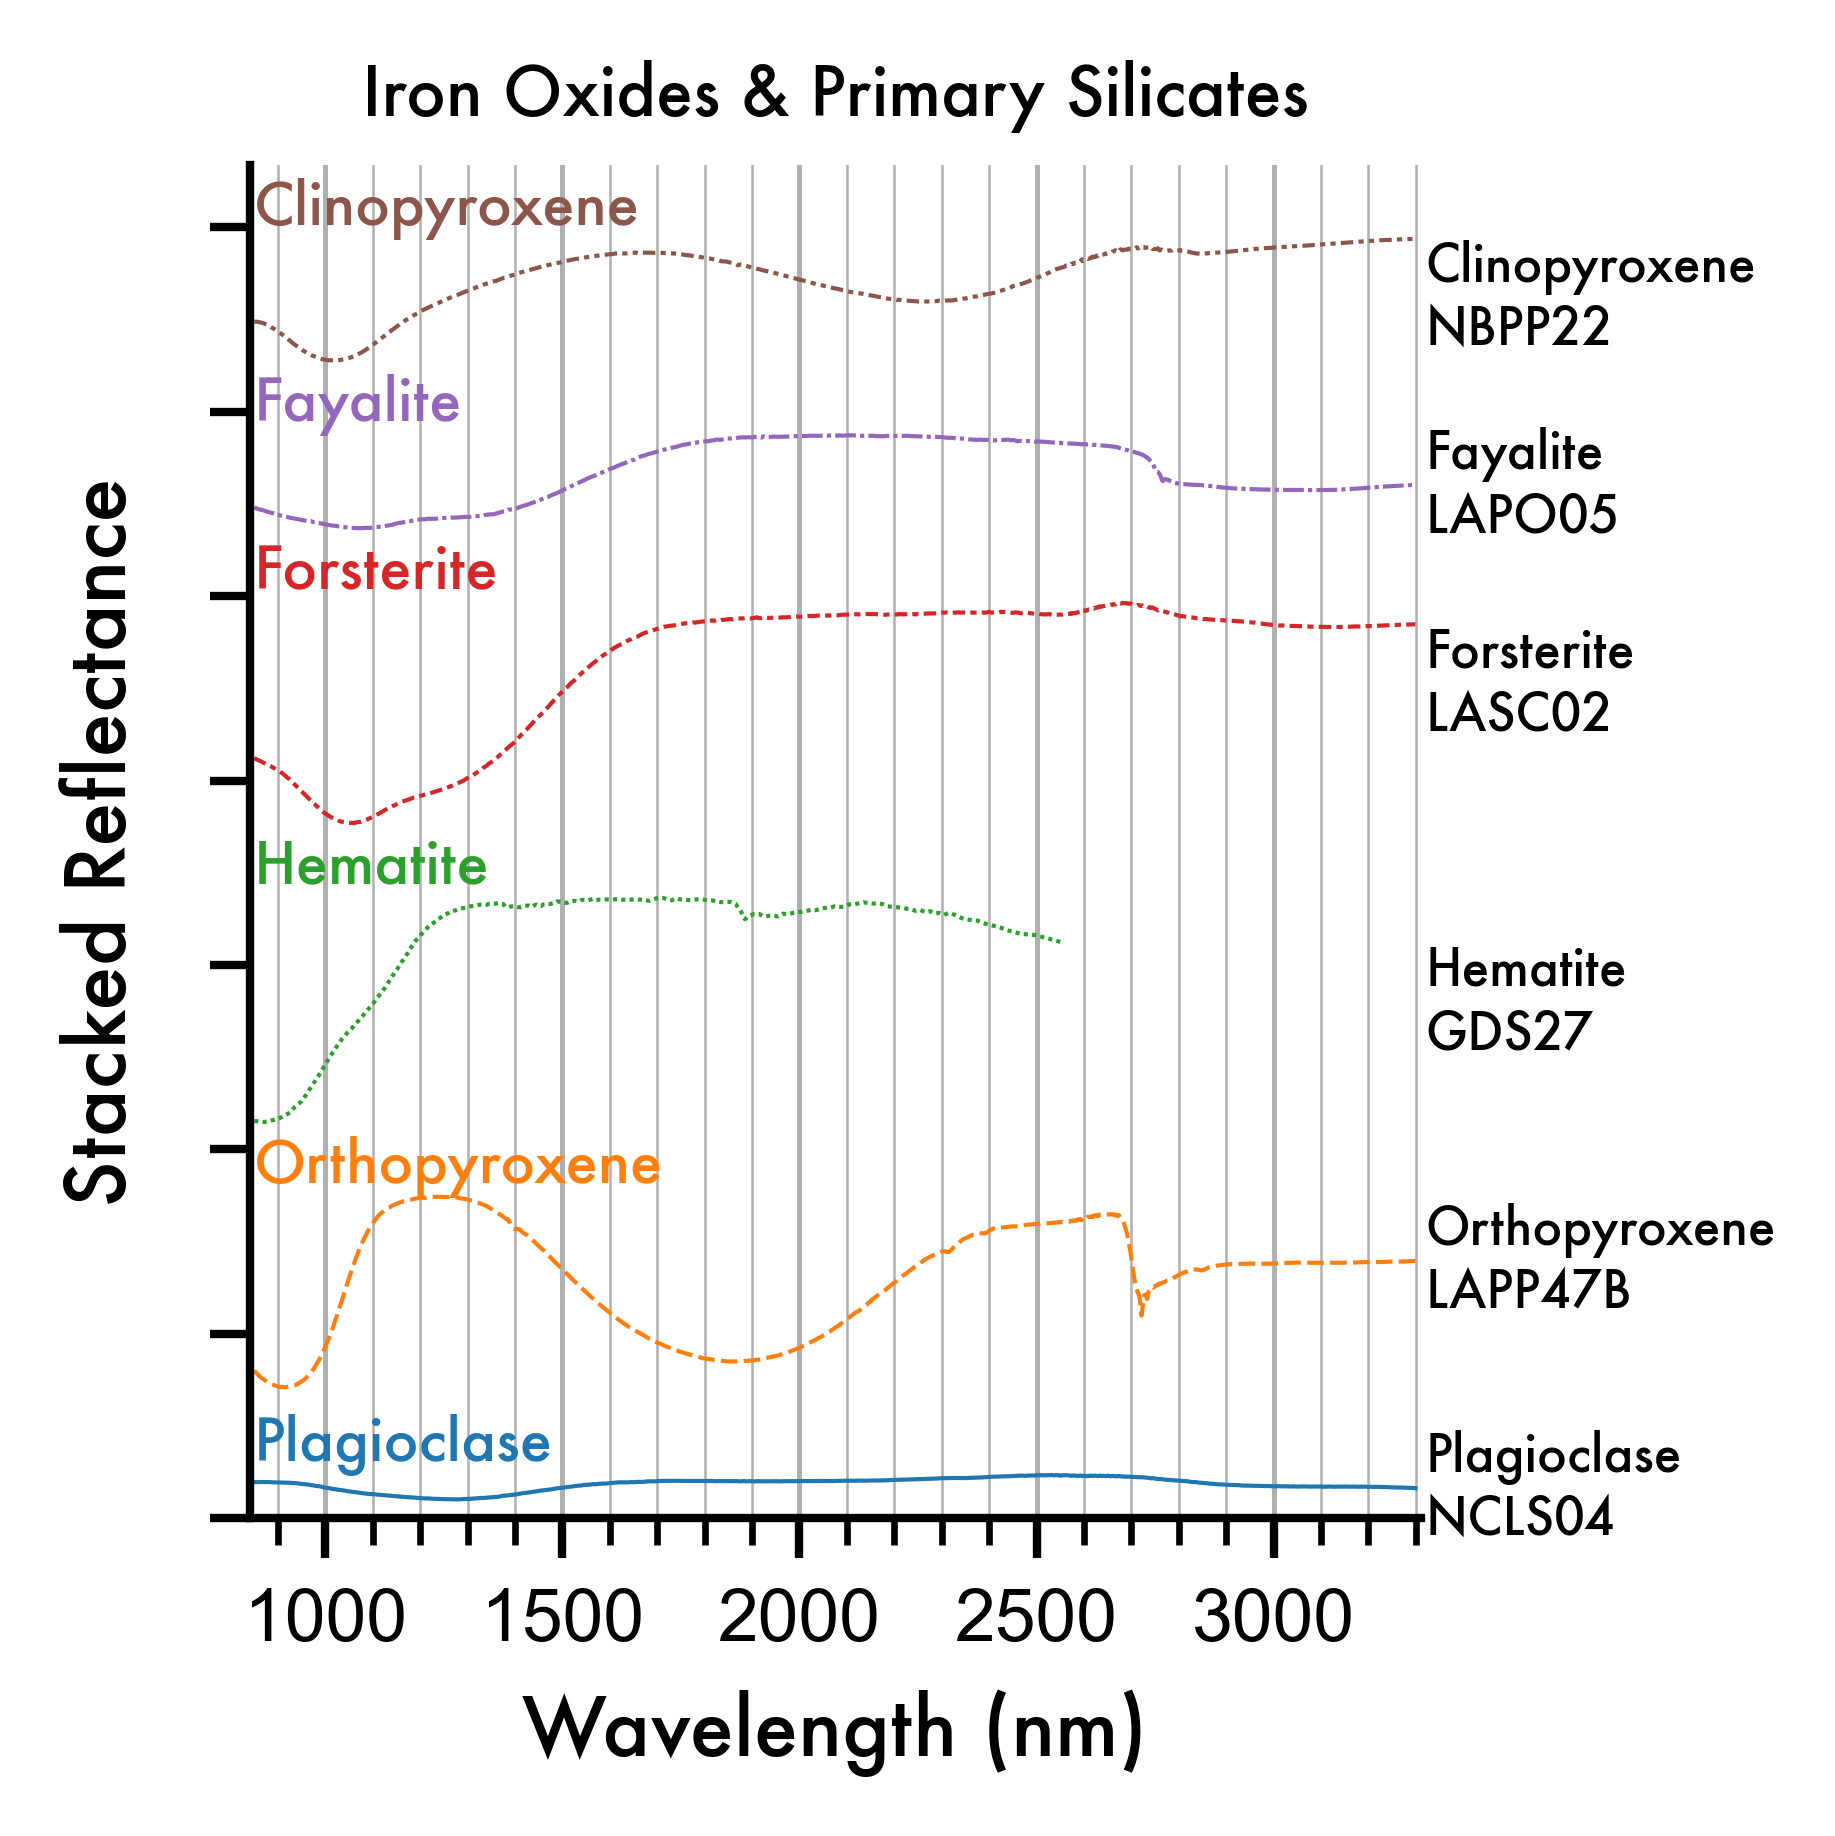

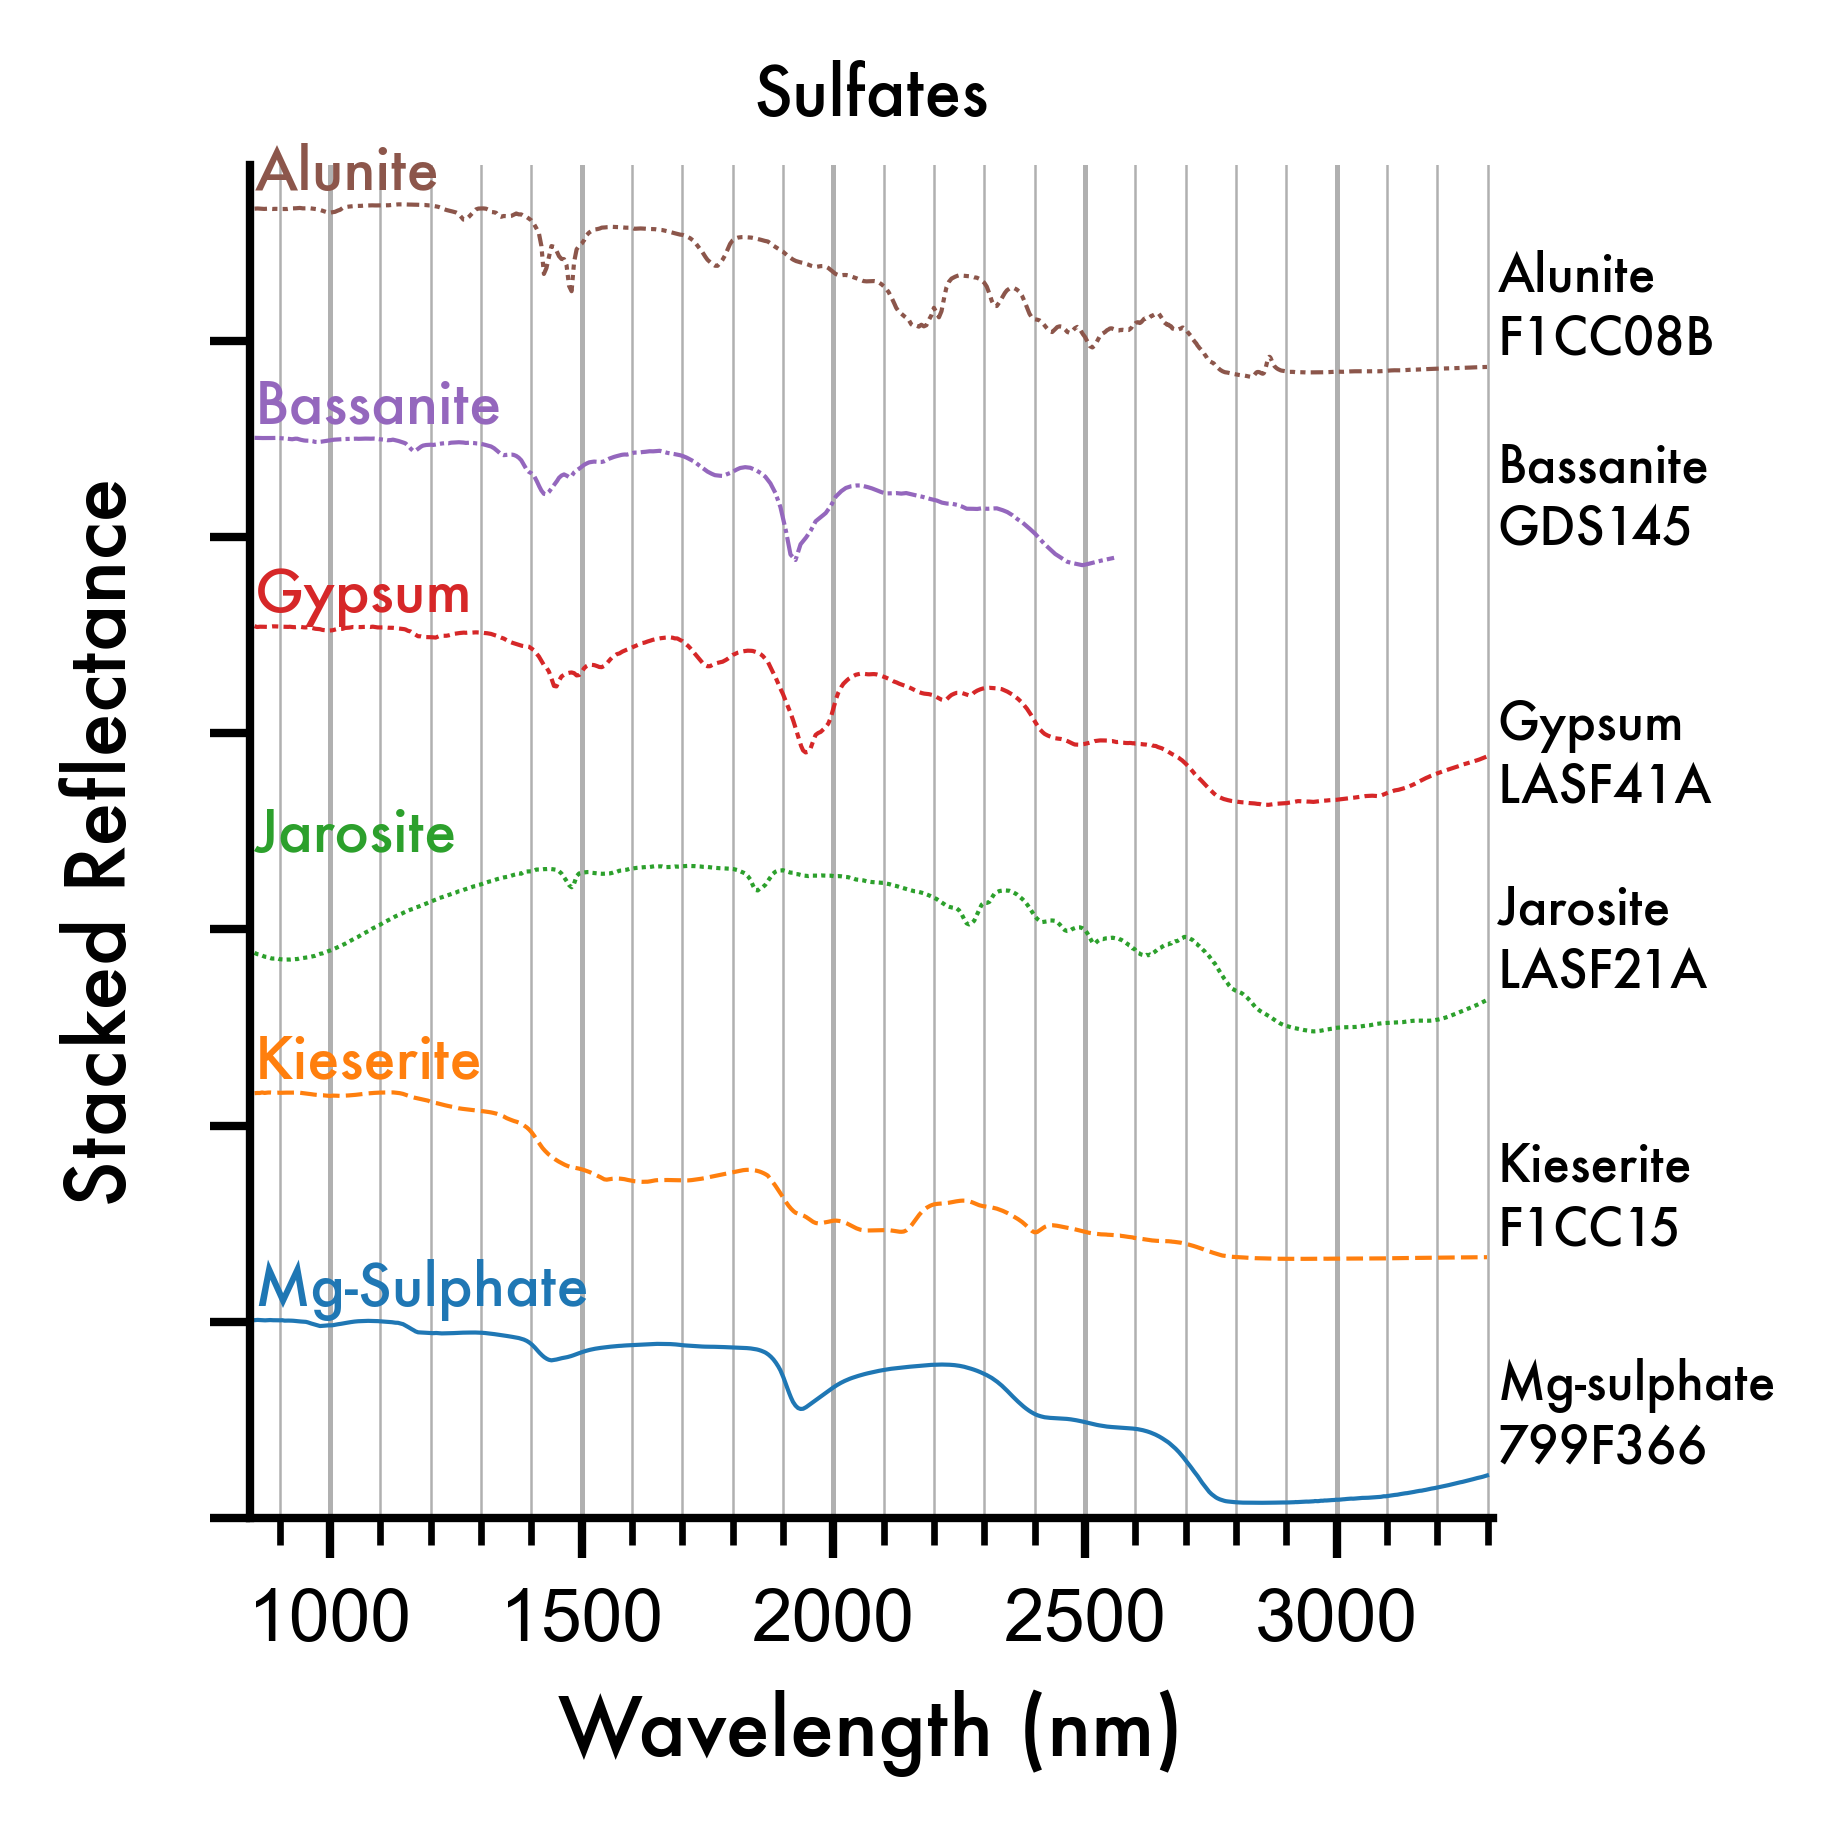

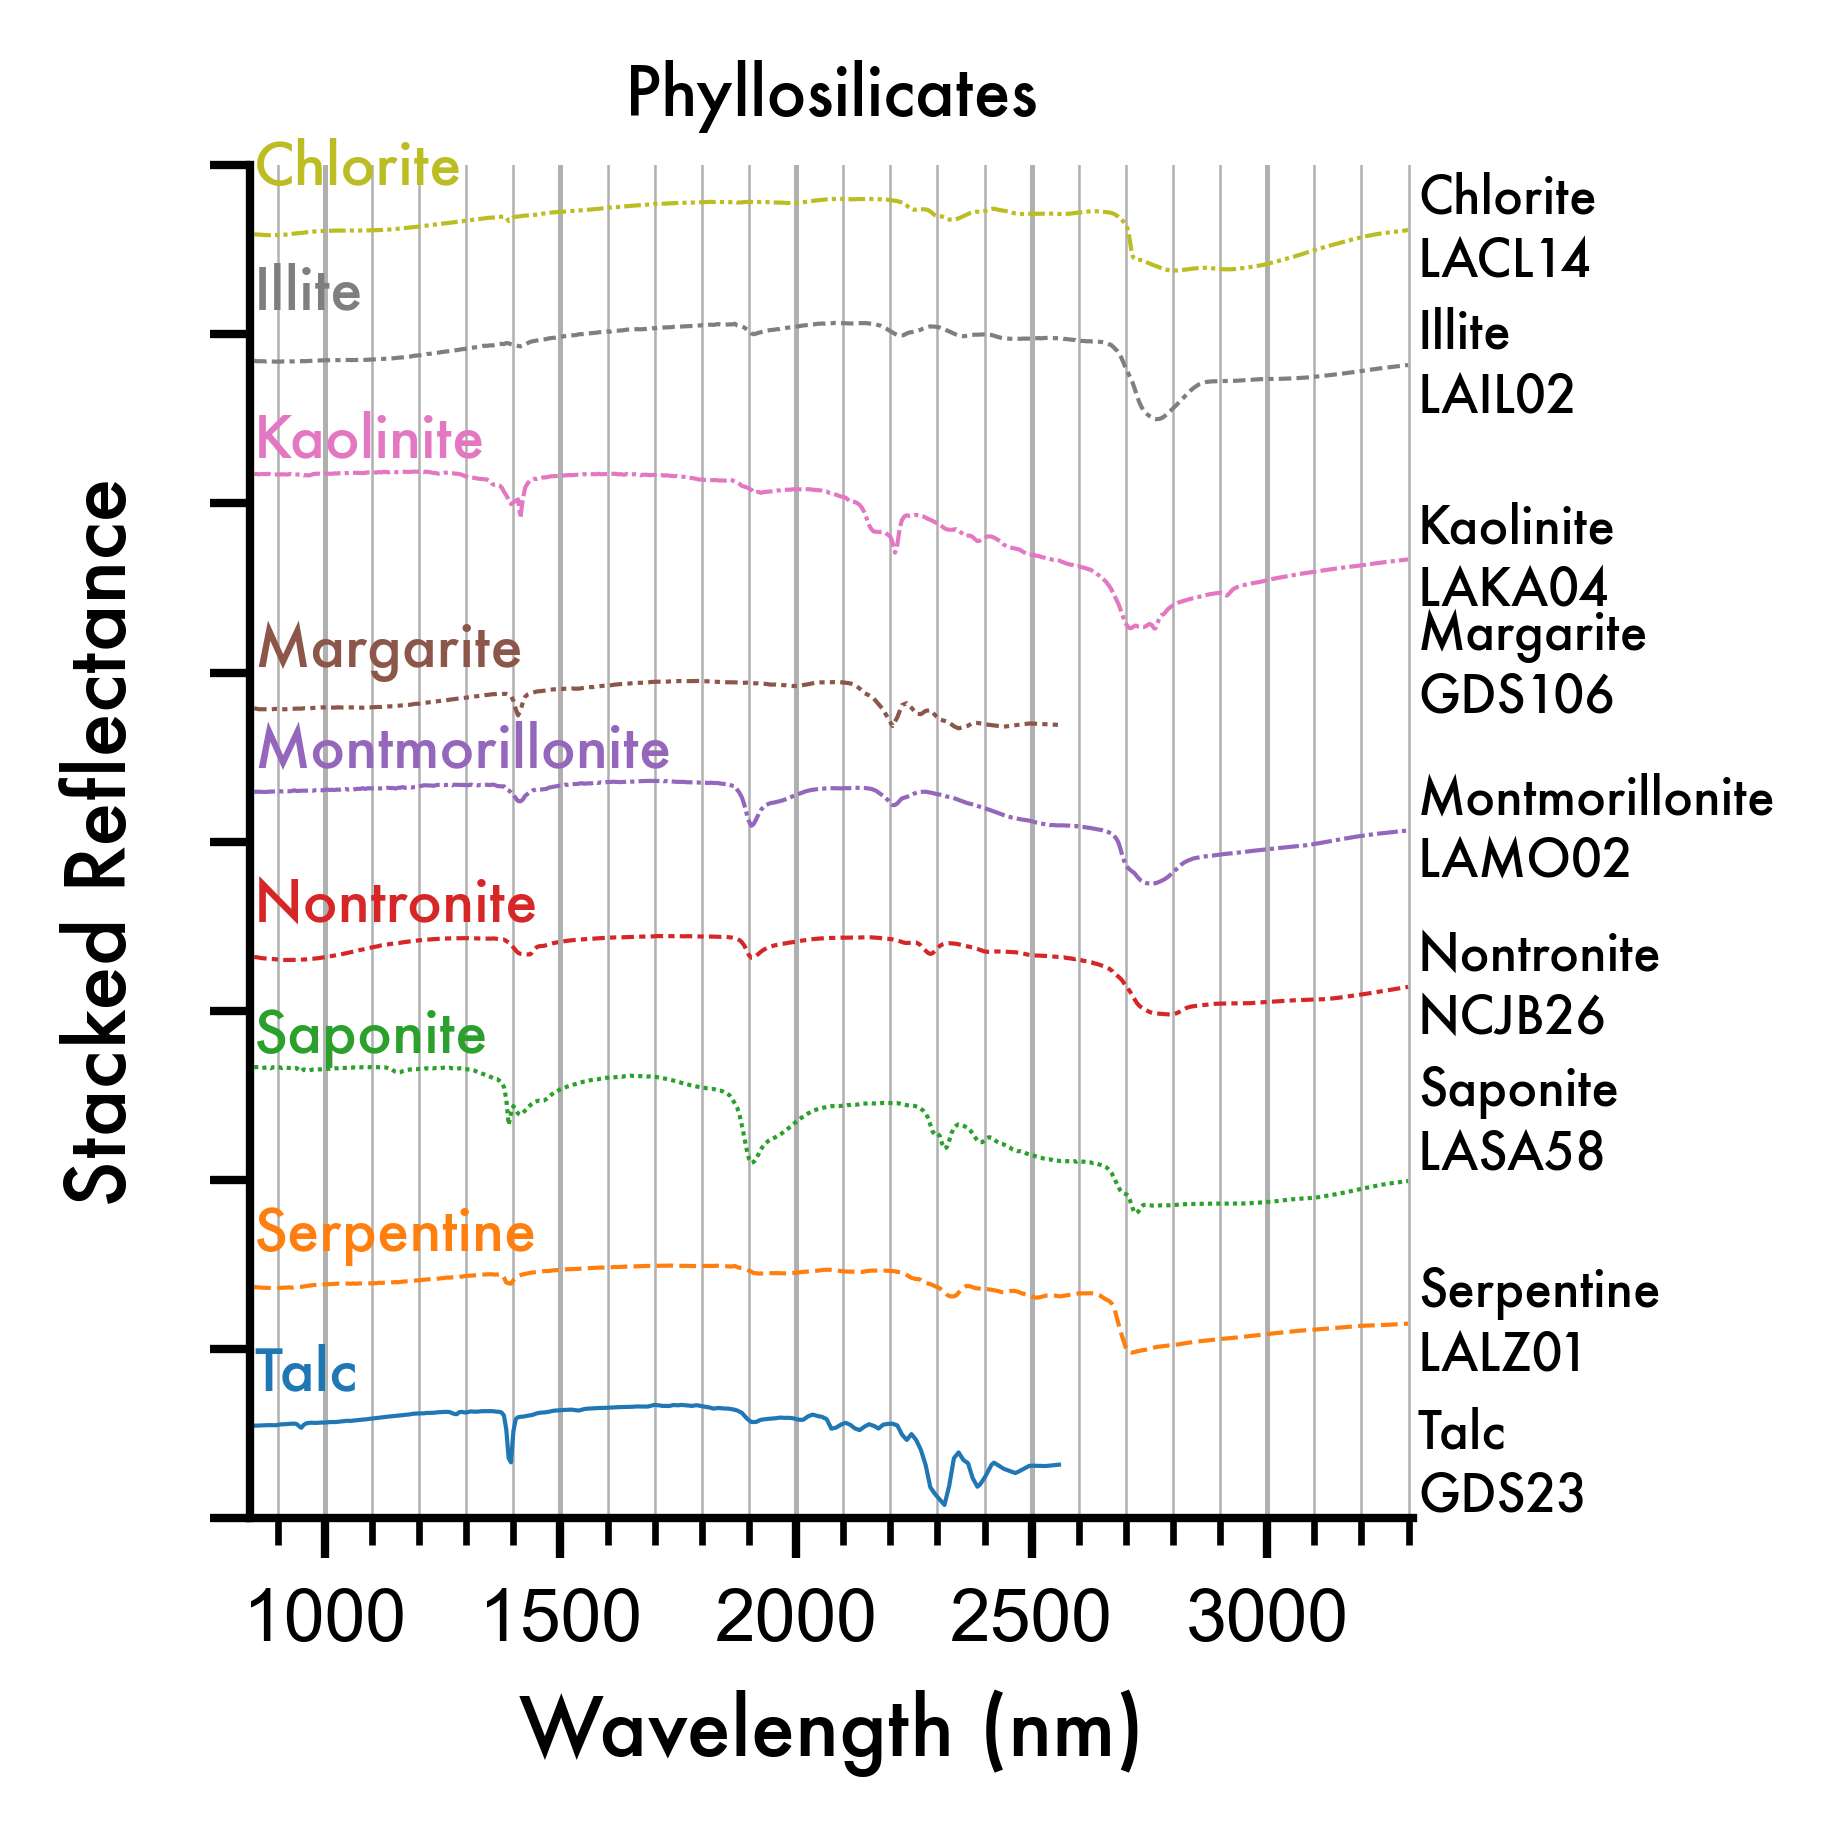

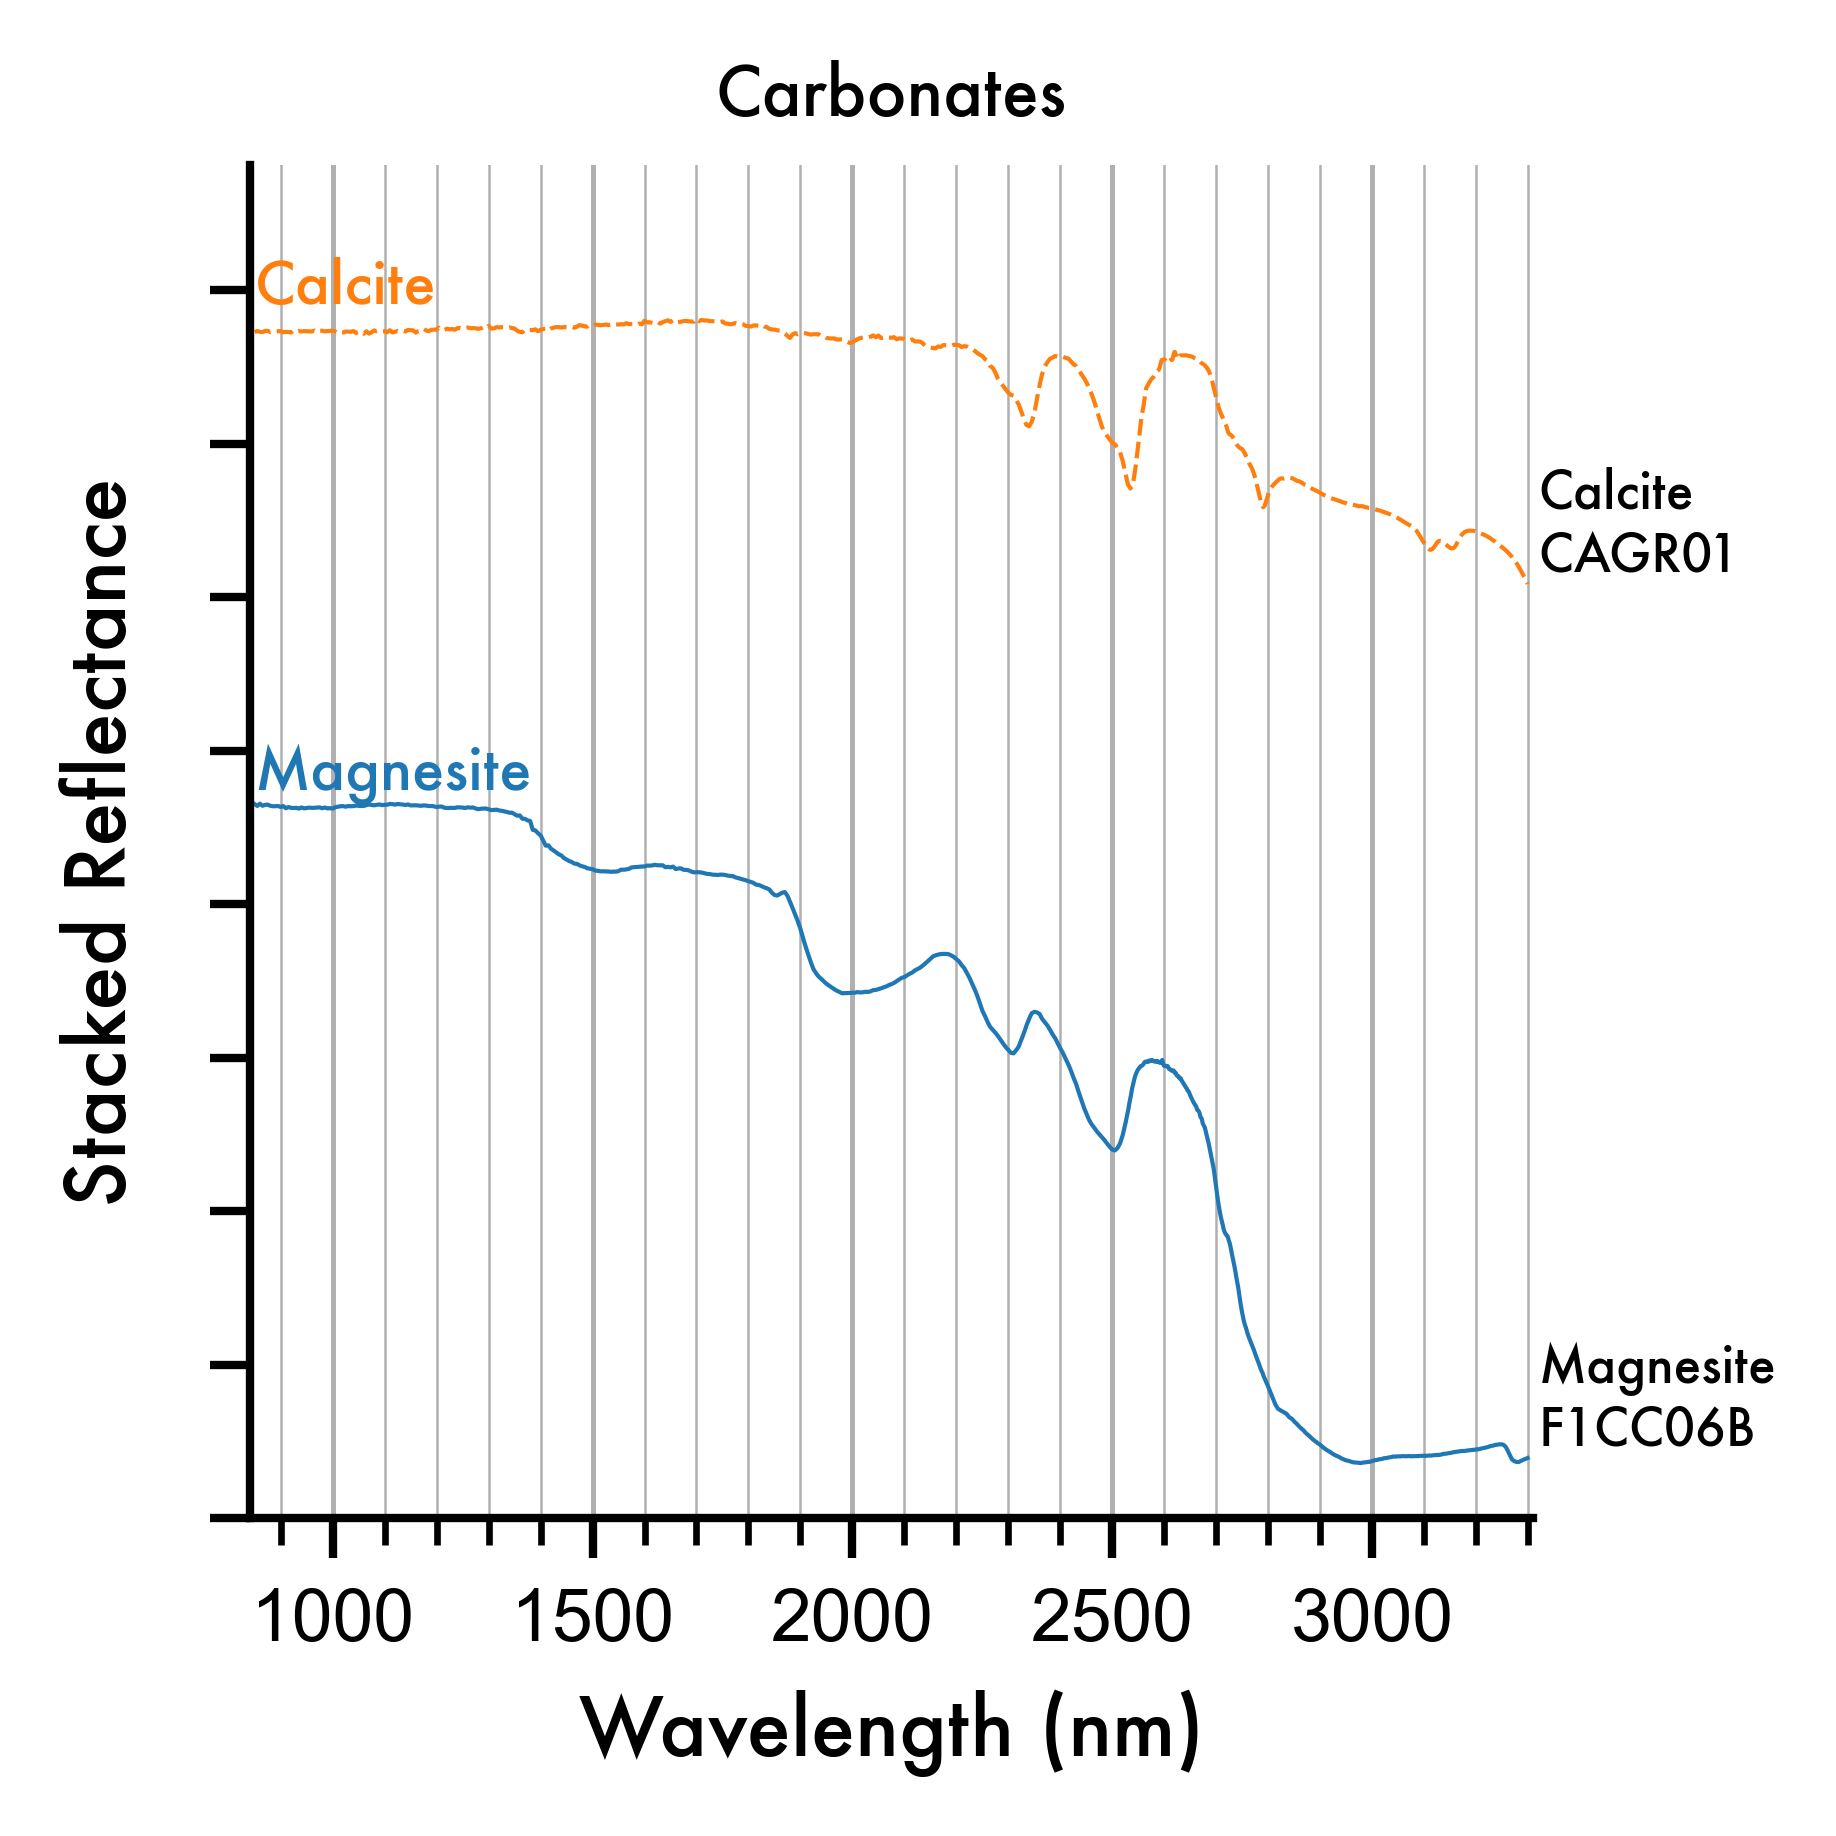

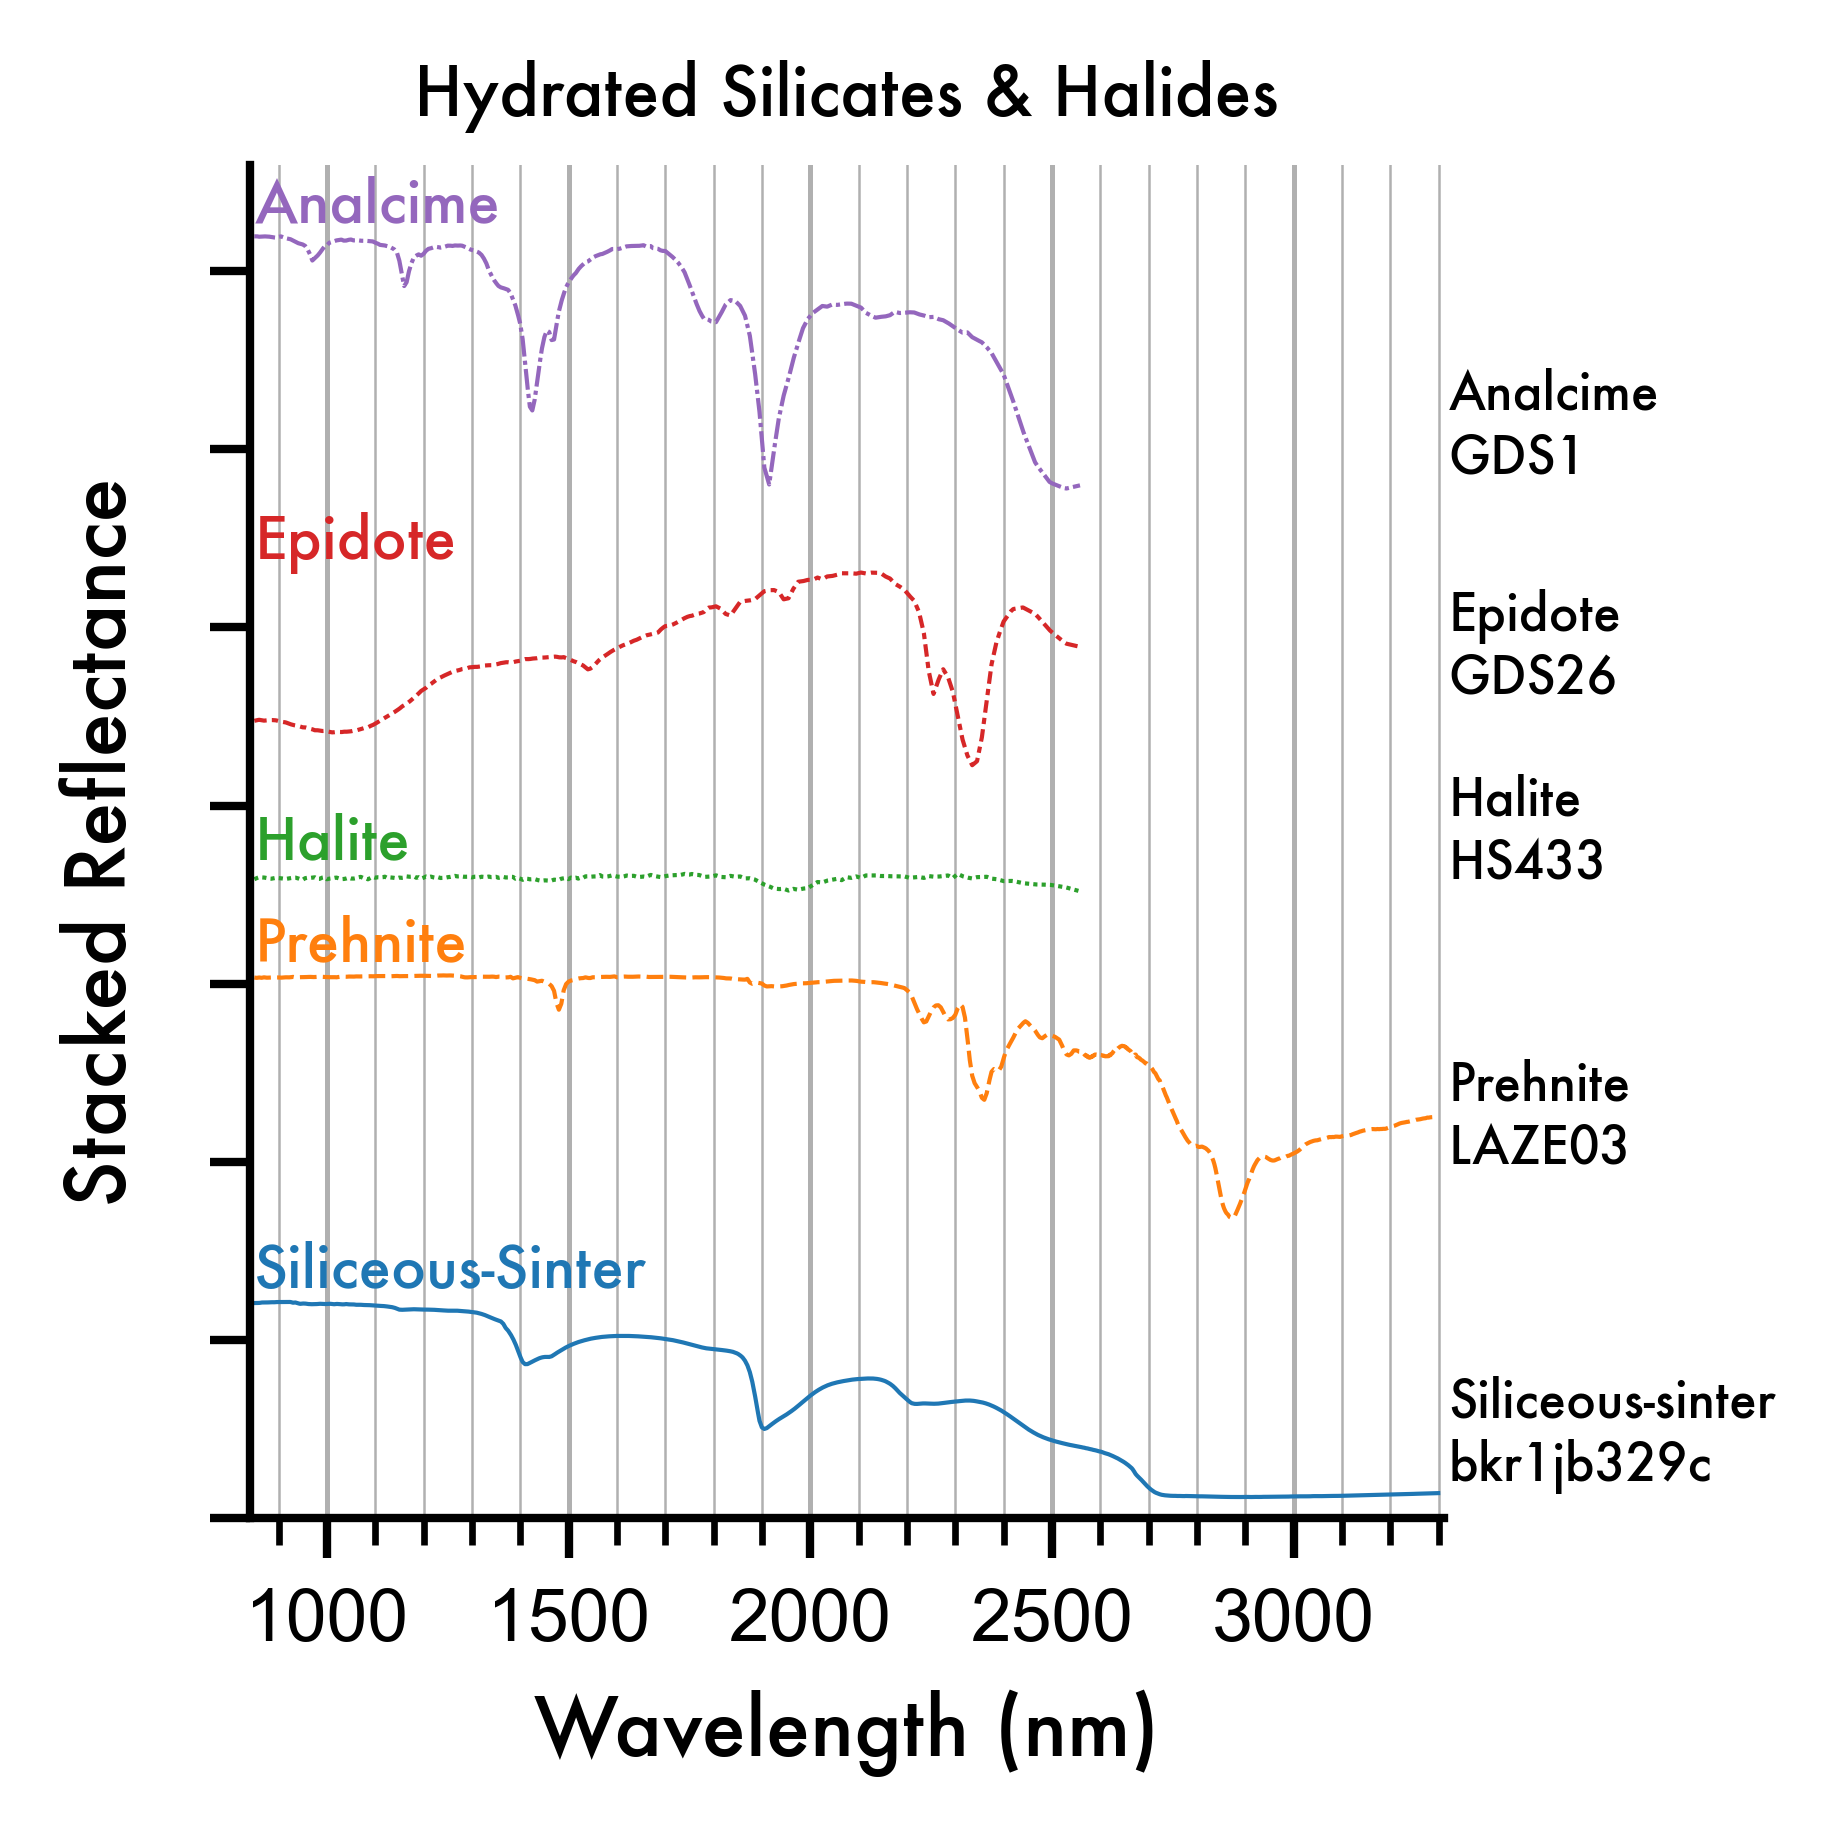

In [20]:
ax = matcol.plot_profiles(stacked=True, scope='categories', groupby='Species')

TO DO: change these plots so they appear next to each other in 2 columns.

# Results

Running of the code, and production of plots.

# Discussion

Notes on what we found above, perhaps with some more analysis.

# Conclusions

Concluding remarks and summary of findings.

# References

Bibliography, ideally managed via Zotero in some way.